# Enviormental Plots 
This is to visualize the data from the main files generated (Enviromental Impact.txt)

As of today the electric emissions in the region are $389.27 gCO_2eq/kWh$

In [2]:
import matplotlib.pyplot as plt

In [3]:
years = [-10, 0, 20, 30, 45, 60, 70]

def plot_this(value_y, label, linestyle='-', linewidth=2):
    first_value = value_y[0]
    last_value = value_y[-1]
    value_y.append(last_value)
    value_y.insert(0, first_value)

    plt.step(years, value_y, label=label, where='pre', linestyle=linestyle, linewidth=linewidth, marker='o', markersize=5)

In [4]:
# Data from the solutions
gCO2eq_kWh_electricity_7L = [389.27, 13.73, 16.35, 20.82, 27.98]
gCO2eq_kWh_electricity_LOMBARDY = [389.27, 376.76, 385.70, 385.56, 385.08]
transport_emissions = [264.75, 264.75, 249.56, 249.55, 249.57]
fossil_fuel_emissions = [550, 550, 414.74, 315.52, 72.60]

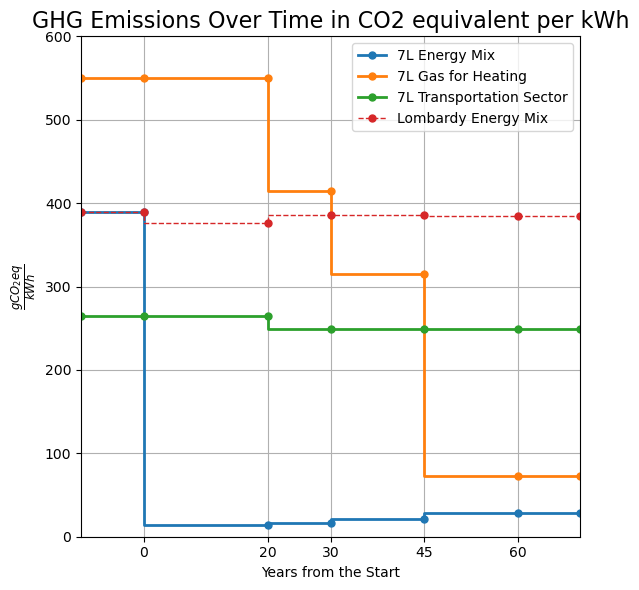

In [5]:
plt.figure(figsize=(6, 6))
plot_this(gCO2eq_kWh_electricity_7L, '7L Energy Mix')
plot_this(fossil_fuel_emissions, '7L Gas for Heating')
plot_this(transport_emissions, '7L Transportation Sector')
plot_this(gCO2eq_kWh_electricity_LOMBARDY, 'Lombardy Energy Mix', '--', 1)
plt.ylim(0, 600)
plt.grid()
plt.legend()
plt.xlim(years[0], years[-1])
plt.xticks(years[1:-1])
plt.xlabel('Years from the Start')
plt.ylabel(r'$\frac{gCO_{2}eq}{kWh}$', fontsize=12)
plt.title('GHG Emissions Over Time in CO2 equivalent per kWh', fontsize=16)
plt.tight_layout()
plt.savefig(f"./Report/figures/5_GHG_emissions_over_time.png", dpi=300, bbox_inches='tight')
plt.show()

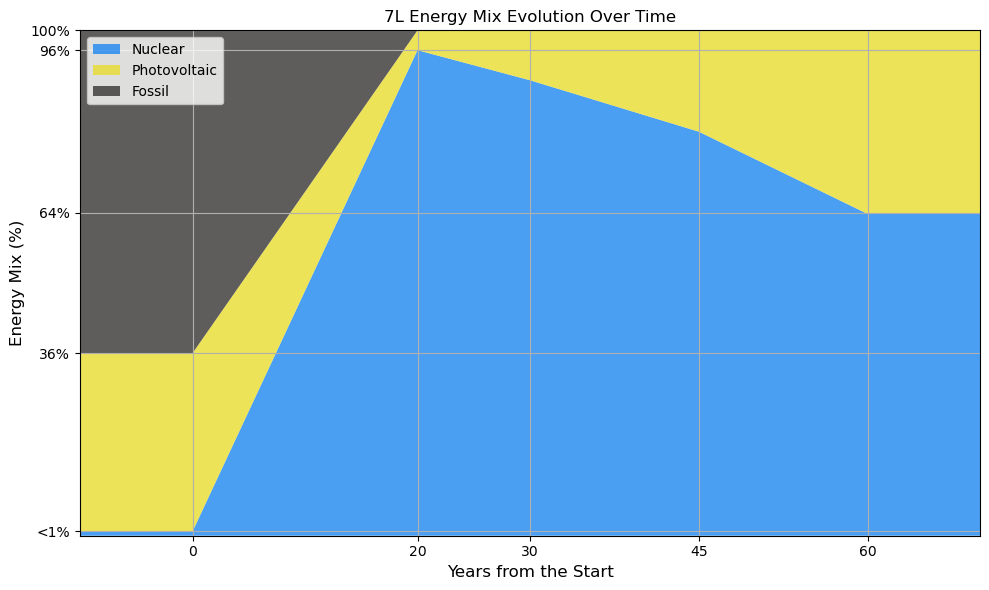

In [6]:
# Stacked plot for the 7L energy mix
energy_source = ["Nuclear", "Photovoltaic", "Fossil"]
energy_mix_evolution = [
    [0.84, 35.28, 63.88],
    [96.07, 3.93,0.00],
    [90.12, 9.88,0.00],
    [79.95, 20.05,0.00],
    [63.68, 36.32,0.00]
]
energy_mix_evolution.append(energy_mix_evolution[-1])  # Append the last year to maintain the same length
energy_mix_evolution.insert(0, energy_mix_evolution[0])  # Insert the first year at the beginning

plt.figure(figsize=(10, 6))
plt.stackplot(years, 
             [energy_mix_evolution[i][0] for i in range(len(energy_mix_evolution))],
             [energy_mix_evolution[i][1] for i in range(len(energy_mix_evolution))],
             [energy_mix_evolution[i][2] for i in range(len(energy_mix_evolution))],
             labels=energy_source, 
             colors=["#1e87ef", "#e8dc2f", "#363433"], 
             alpha=0.8)
plt.xlim(years[0], years[-1])
plt.xticks(years[1:-1])
plt.xlabel('Years from the Start', fontsize=12)
plt.ylabel('Energy Mix (%)', fontsize=12)
plt.yticks([0.84, 35.28+0.84, 63.88, 96.07, 63.88+35.28+0.84])
ax = plt.gca()
ax.set_yticklabels(['<1%', '36%', '64%', '96%', '100%'])
plt.ylim(0, 100)
plt.title('7L Energy Mix Evolution Over Time')
plt.grid()
plt.tight_layout()
plt.legend(loc='upper left')
plt.savefig(f"./Report/figures/5_Energy_mix_evolution.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Simo\AppData\Local\Temp\ipykernel_17168\2772074402.py:20: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 2500)


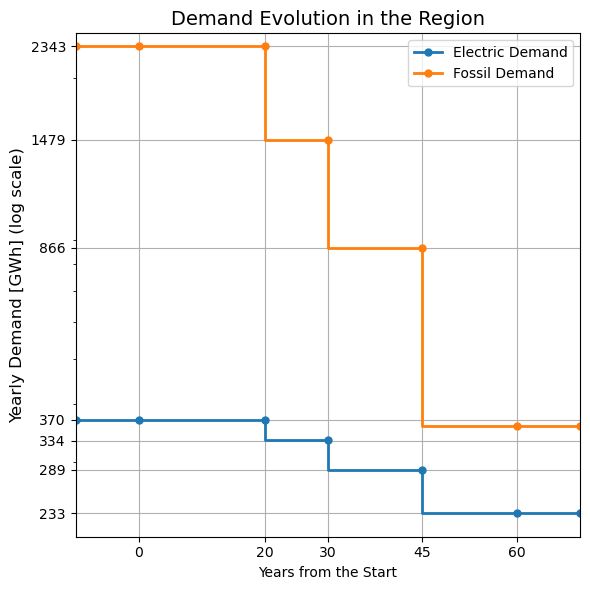

In [7]:
electric_demand = [369.26, 369.26, 334.19, 288.88, 232.99]
fossil_demand = [2342.5, 2342.5, 1478.86, 866.28, 359.05]

plt.figure(figsize=(6, 6))

plot_this(electric_demand, 'Electric Demand')
plot_this(fossil_demand, 'Fossil Demand')

plt.title('Demand Evolution in the Region', fontsize=14)

plt.xlim(years[0], years[-1])
plt.xticks(years[1:-1])
plt.xlabel('Years from the Start')
plt.yscale('log')
plt.ylabel('Yearly Demand [GWh] (log scale)', fontsize=12)
plt.yticks([370, 334, 289, 233, 2343, 1479, 866])
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter())
plt.grid()
plt.legend()
plt.ylim(0, 2500)
plt.tight_layout()
plt.savefig(f"./Report/figures/5_Demand_evolution.png", dpi=300, bbox_inches='tight')
plt.show()


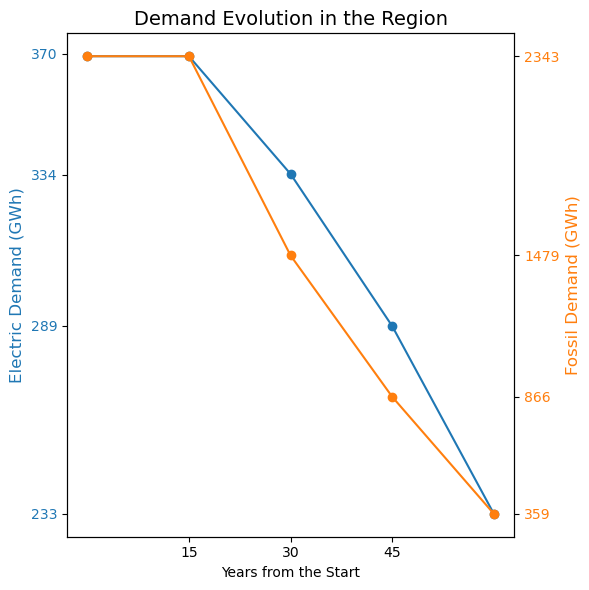

In [8]:
import matplotlib.pyplot as plt
import numpy as np

electric_demand = np.array([369.26, 369.26, 334.19, 288.88, 232.99])
fossil_demand = np.array([2342.5, 2342.5, 1478.86, 866.28, 359.05])
years = [0, 15, 30, 45, 60]

# Normalize to [0, 1] range
elec_norm = (electric_demand - electric_demand.min()) / (electric_demand.max() - electric_demand.min())
fossil_norm = (fossil_demand - fossil_demand.min()) / (fossil_demand.max() - fossil_demand.min())

fig, ax1 = plt.subplots(figsize=(6, 6))

# Plot normalized electric demand
ax1.plot(years, elec_norm, 'o-', label='Electric Demand', color='tab:blue')
ax1.set_ylabel('Electric Demand (GWh)', fontsize=12, color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(years[1:-1])
ax1.set_xlabel('Years from the Start')
ax1.set_title('Demand Evolution in the Region', fontsize=14)

# Custom ticks on left axis (Electric)
elec_ticks = [370, 334, 289, 233]
elec_tick_pos = (np.array(elec_ticks) - electric_demand.min()) / (electric_demand.max() - electric_demand.min())
ax1.set_yticks(elec_tick_pos)
ax1.set_yticklabels([str(x) for x in elec_ticks])

# Twin axis for fossil demand
ax2 = ax1.twinx()
ax2.plot(years, fossil_norm, 'o-', label='Fossil Demand', color='tab:orange')
ax2.set_ylabel('Fossil Demand (GWh)', fontsize=12, color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Custom ticks on right axis (Fossil)
fossil_ticks = [2343, 1479, 866, 359]
fossil_tick_pos = (np.array(fossil_ticks) - fossil_demand.min()) / (fossil_demand.max() - fossil_demand.min())
ax2.set_yticks(fossil_tick_pos)
ax2.set_yticklabels([str(x) for x in fossil_ticks])

plt.tight_layout()
plt.show()
